In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
%matplotlib inline

In [2]:
url = "https://www.dropbox.com/scl/fi/giaj8trfbz6q896wqy63r/_train_sem2.csv?rlkey=az8c3cakn3d9mni5y1opv04pm&e=1&dl=1"
data = pd.read_csv(url)
data = data.drop_duplicates()

print("Размер данных:", data.shape)
data.head()

Размер данных: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
data = data.drop(columns=["Id"])

quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ordinal_cols = ["ExterQual", "KitchenQual", "BsmtQual", "HeatingQC", "GarageQual", "PoolQC"]

for col in ordinal_cols:
    data[col] = data[col].fillna("None").map(quality_map)

cat_cols = data.select_dtypes(include=["str"]).columns.tolist()
print("Категориальные признаки (номинальные):", len(cat_cols))
print(cat_cols)

Категориальные признаки (номинальные): 37
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCond', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [4]:
data["OverallQualityScore"] = data[
    ["ExterQual", "KitchenQual", "BsmtQual", "GarageQual", "HeatingQC"]
].sum(axis=1)

data["HouseAge"] = data["YrSold"] - data["YearBuilt"]
data["YearsSinceRemodel"] = data["YrSold"] - data["YearRemodAdd"]
data["GarageAge"] = data["YrSold"] - data["GarageYrBlt"]
data["WasRemodeled"] = (data["YearBuilt"] != data["YearRemodAdd"]).astype(int)

data["TotalSF"] = data["TotalBsmtSF"] + data["1stFlrSF"] + data["2ndFlrSF"]
data["TotalPorchSF"] = (
    data["OpenPorchSF"] + data["EnclosedPorch"] +
    data["3SsnPorch"] + data["ScreenPorch"] + data["WoodDeckSF"]
)
data["TotalBathrooms"] = (
    data["FullBath"] + 0.5 * data["HalfBath"] +
    data["BsmtFullBath"] + 0.5 * data["BsmtHalfBath"]
)

data["HasPool"] = (data["PoolArea"] > 0).astype(int)
data["Has2ndFloor"] = (data["2ndFlrSF"] > 0).astype(int)
data["HasBasement"] = (data["TotalBsmtSF"] > 0).astype(int)
data["HasGarage"] = (data["GarageArea"] > 0).astype(int)
data["HasFireplace"] = (data["Fireplaces"] > 0).astype(int)

new_features = [
    "OverallQualityScore", "HouseAge", "YearsSinceRemodel", "GarageAge", "WasRemodeled",
    "TotalSF", "TotalPorchSF", "TotalBathrooms",
    "HasPool", "Has2ndFloor", "HasBasement", "HasGarage", "HasFireplace"
]

print("Новые признаки:", len(new_features))
print(new_features)

Новые признаки: 13
['OverallQualityScore', 'HouseAge', 'YearsSinceRemodel', 'GarageAge', 'WasRemodeled', 'TotalSF', 'TotalPorchSF', 'TotalBathrooms', 'HasPool', 'Has2ndFloor', 'HasBasement', 'HasGarage', 'HasFireplace']


In [5]:
print("Общая информация: \n")
data.info()

Общая информация: 

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 93 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MSSubClass           1460 non-null   int64  
 1   MSZoning             1460 non-null   str    
 2   LotFrontage          1201 non-null   float64
 3   LotArea              1460 non-null   int64  
 4   Street               1460 non-null   str    
 5   Alley                91 non-null     str    
 6   LotShape             1460 non-null   str    
 7   LandContour          1460 non-null   str    
 8   Utilities            1460 non-null   str    
 9   LotConfig            1460 non-null   str    
 10  LandSlope            1460 non-null   str    
 11  Neighborhood         1460 non-null   str    
 12  Condition1           1460 non-null   str    
 13  Condition2           1460 non-null   str    
 14  BldgType             1460 non-null   str    
 15  HouseStyle           1460 non

In [6]:
cat_columns = data.select_dtypes(include=["str"]).columns
print("Категориальные столбцы до преобразования:\n", list(cat_columns))

data_cat_backup = data[cat_columns].copy()

for col in cat_columns:
    data[col] = data[col].astype("category").cat.codes
print("\nТипы столбцов после преобразования:")
print(data.dtypes.value_counts())

Категориальные столбцы до преобразования:
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCond', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Типы столбцов после преобразования:
int64      51
int8       37
float64     5
Name: count, dtype: int64


In [7]:
print("Описание признаков:\n")
print(data.describe())

Описание признаков:

        MSSubClass     MSZoning  LotFrontage        LotArea       Street  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean     56.897260     3.028767    70.049958   10516.828082     0.995890   
std      42.300571     0.632017    24.284752    9981.264932     0.063996   
min      20.000000     0.000000    21.000000    1300.000000     0.000000   
25%      20.000000     3.000000    59.000000    7553.500000     1.000000   
50%      50.000000     3.000000    69.000000    9478.500000     1.000000   
75%      70.000000     3.000000    80.000000   11601.500000     1.000000   
max     190.000000     4.000000   313.000000  215245.000000     1.000000   

             Alley     LotShape  LandContour    Utilities    LotConfig  ...  \
count  1460.000000  1460.000000  1460.000000  1460.000000  1460.000000  ...   
mean     -0.909589     1.942466     2.777397     0.000685     3.019178  ...   
std       0.372151     1.409156     0.707666     0.026171

In [8]:
missing_values = data.isnull().sum().sort_values(ascending=False)
print("Количество пропущенных значений:\n")
print(missing_values[missing_values > 0])

Количество пропущенных значений:

LotFrontage    259
GarageAge       81
GarageYrBlt     81
MasVnrArea       8
dtype: int64


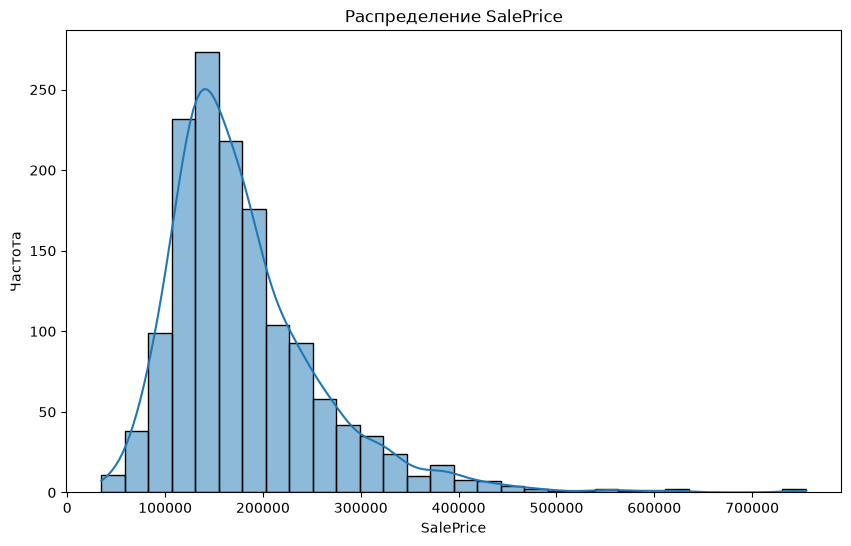

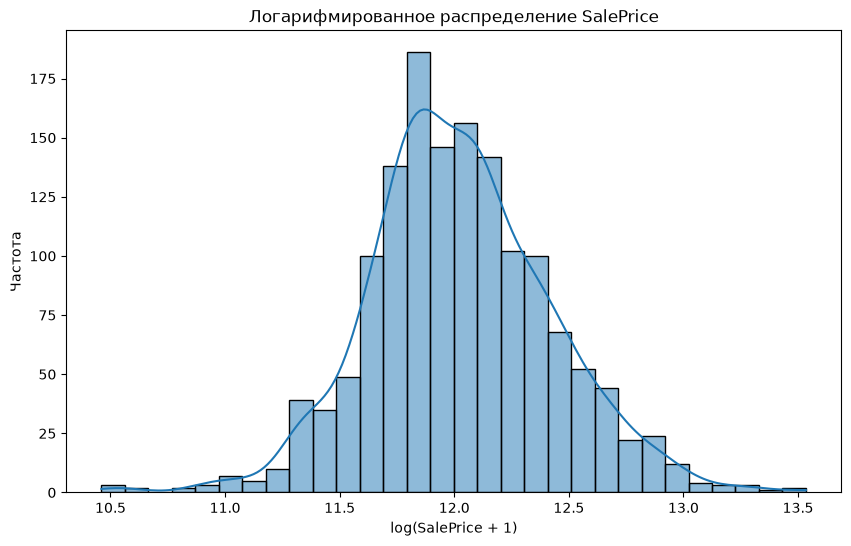

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data["SalePrice"], kde=True, bins=30)
plt.title("Распределение SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Частота")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(data["SalePrice"]), kde=True, bins=30)
plt.title("Логарифмированное распределение SalePrice")
plt.xlabel("log(SalePrice + 1)")
plt.ylabel("Частота")
plt.show()

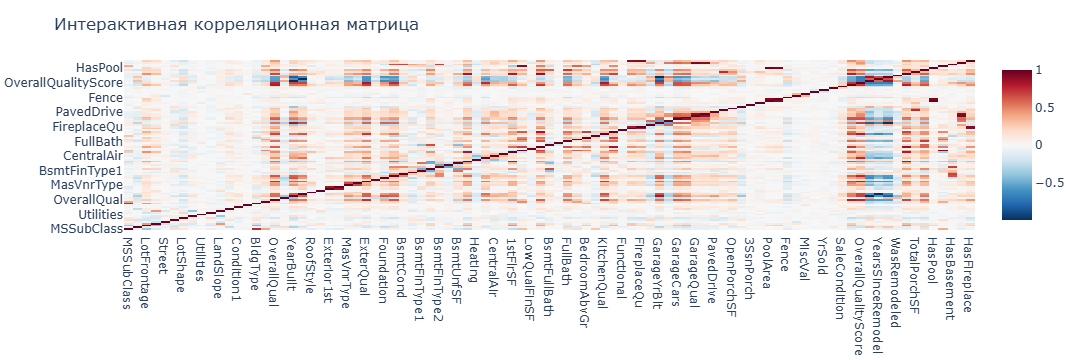

Корреляция с SalePrice:

SalePrice              1.000000
OverallQual            0.790982
TotalSF                0.782260
OverallQualityScore    0.716344
GrLivArea              0.708624
ExterQual              0.682639
KitchenQual            0.659600
GarageCars             0.640409
TotalBathrooms         0.631731
GarageArea             0.623431
TotalBsmtSF            0.613581
1stFlrSF               0.605852
BsmtQual               0.585207
FullBath               0.560664
TotRmsAbvGrd           0.533723
YearBuilt              0.522897
YearRemodAdd           0.507101
GarageYrBlt            0.486362
MasVnrArea             0.477493
HasFireplace           0.471908
Fireplaces             0.466929
HeatingQC              0.427649
MasVnrType             0.411798
TotalPorchSF           0.390993
BsmtFinSF1             0.386420
Foundation             0.382479
FireplaceQu            0.378377
LotFrontage            0.351799
WoodDeckSF             0.324413
2ndFlrSF               0.319334
OpenPorchSF    

<Figure size 1600x1400 with 0 Axes>

In [10]:
plt.figure(figsize=(16, 14))
corr_matrix = data.corr()
fig = px.imshow(corr_matrix, text_auto=True, aspect="auto",
                color_continuous_scale="RdBu_r", origin="lower")
fig.update_layout(title="Интерактивная корреляционная матрица")
fig.show()

corr_with_target = corr_matrix["SalePrice"].sort_values(ascending=False)

pd.set_option('display.max_rows', None)

print("Корреляция с SalePrice:\n")
print(corr_with_target)

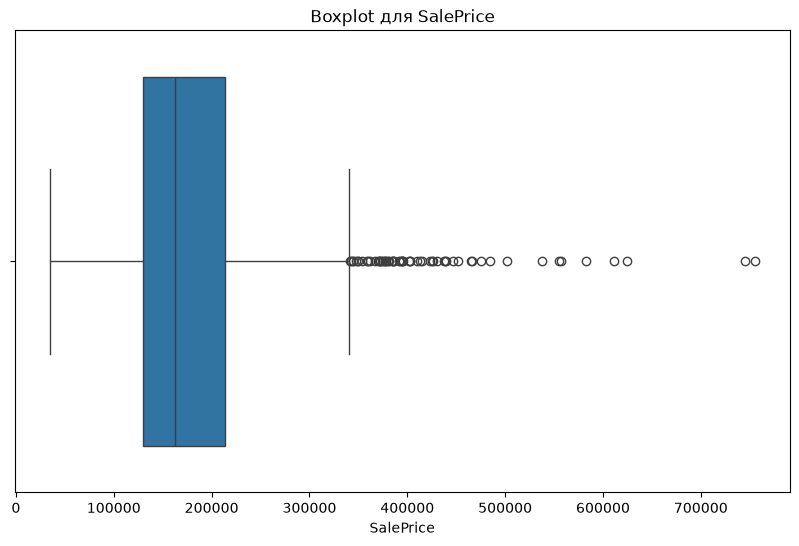

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data["SalePrice"])
plt.title("Boxplot для SalePrice")
plt.show()


In [12]:
corr_matrix = data.corr(numeric_only=True)
corr_with_target = corr_matrix["SalePrice"].sort_values(ascending=False)
print(corr_with_target.head(15))

top_features = corr_with_target.drop("SalePrice").abs().sort_values(ascending=False).head(8).index.tolist()
print("\nПризнаки для проверки на выбросы:", top_features)

SalePrice              1.000000
OverallQual            0.790982
TotalSF                0.782260
OverallQualityScore    0.716344
GrLivArea              0.708624
ExterQual              0.682639
KitchenQual            0.659600
GarageCars             0.640409
TotalBathrooms         0.631731
GarageArea             0.623431
TotalBsmtSF            0.613581
1stFlrSF               0.605852
BsmtQual               0.585207
FullBath               0.560664
TotRmsAbvGrd           0.533723
Name: SalePrice, dtype: float64

Признаки для проверки на выбросы: ['OverallQual', 'TotalSF', 'OverallQualityScore', 'GrLivArea', 'ExterQual', 'KitchenQual', 'GarageCars', 'TotalBathrooms']


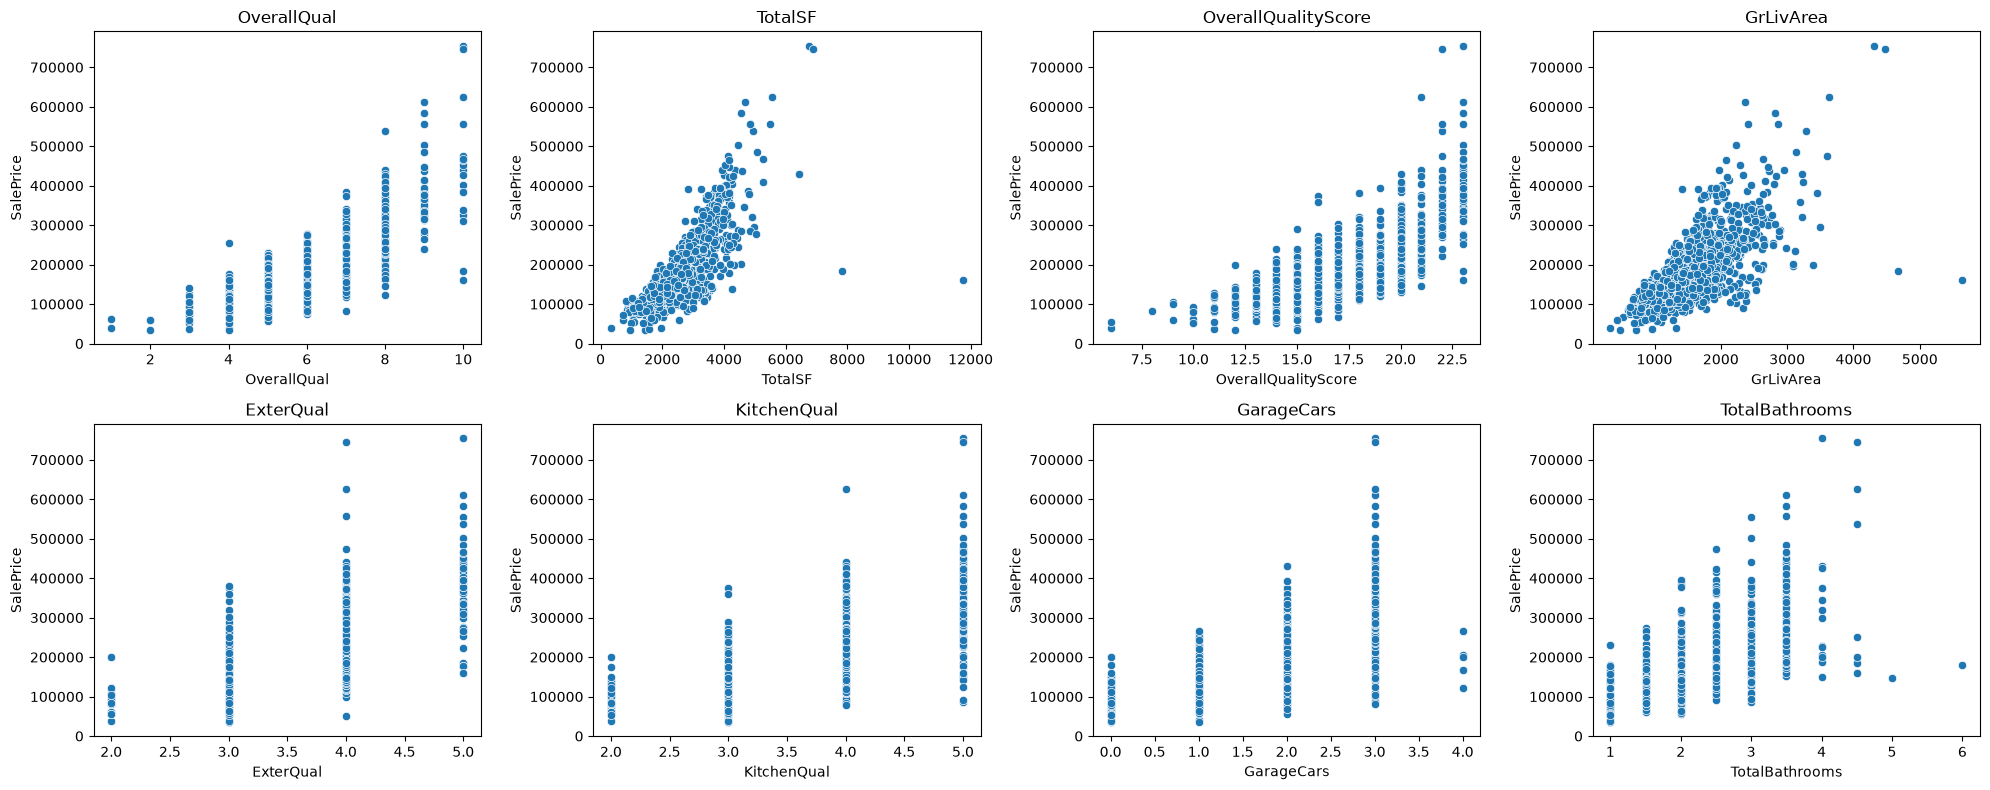

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), top_features):
    sns.scatterplot(x=data[col], y=data["SalePrice"], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

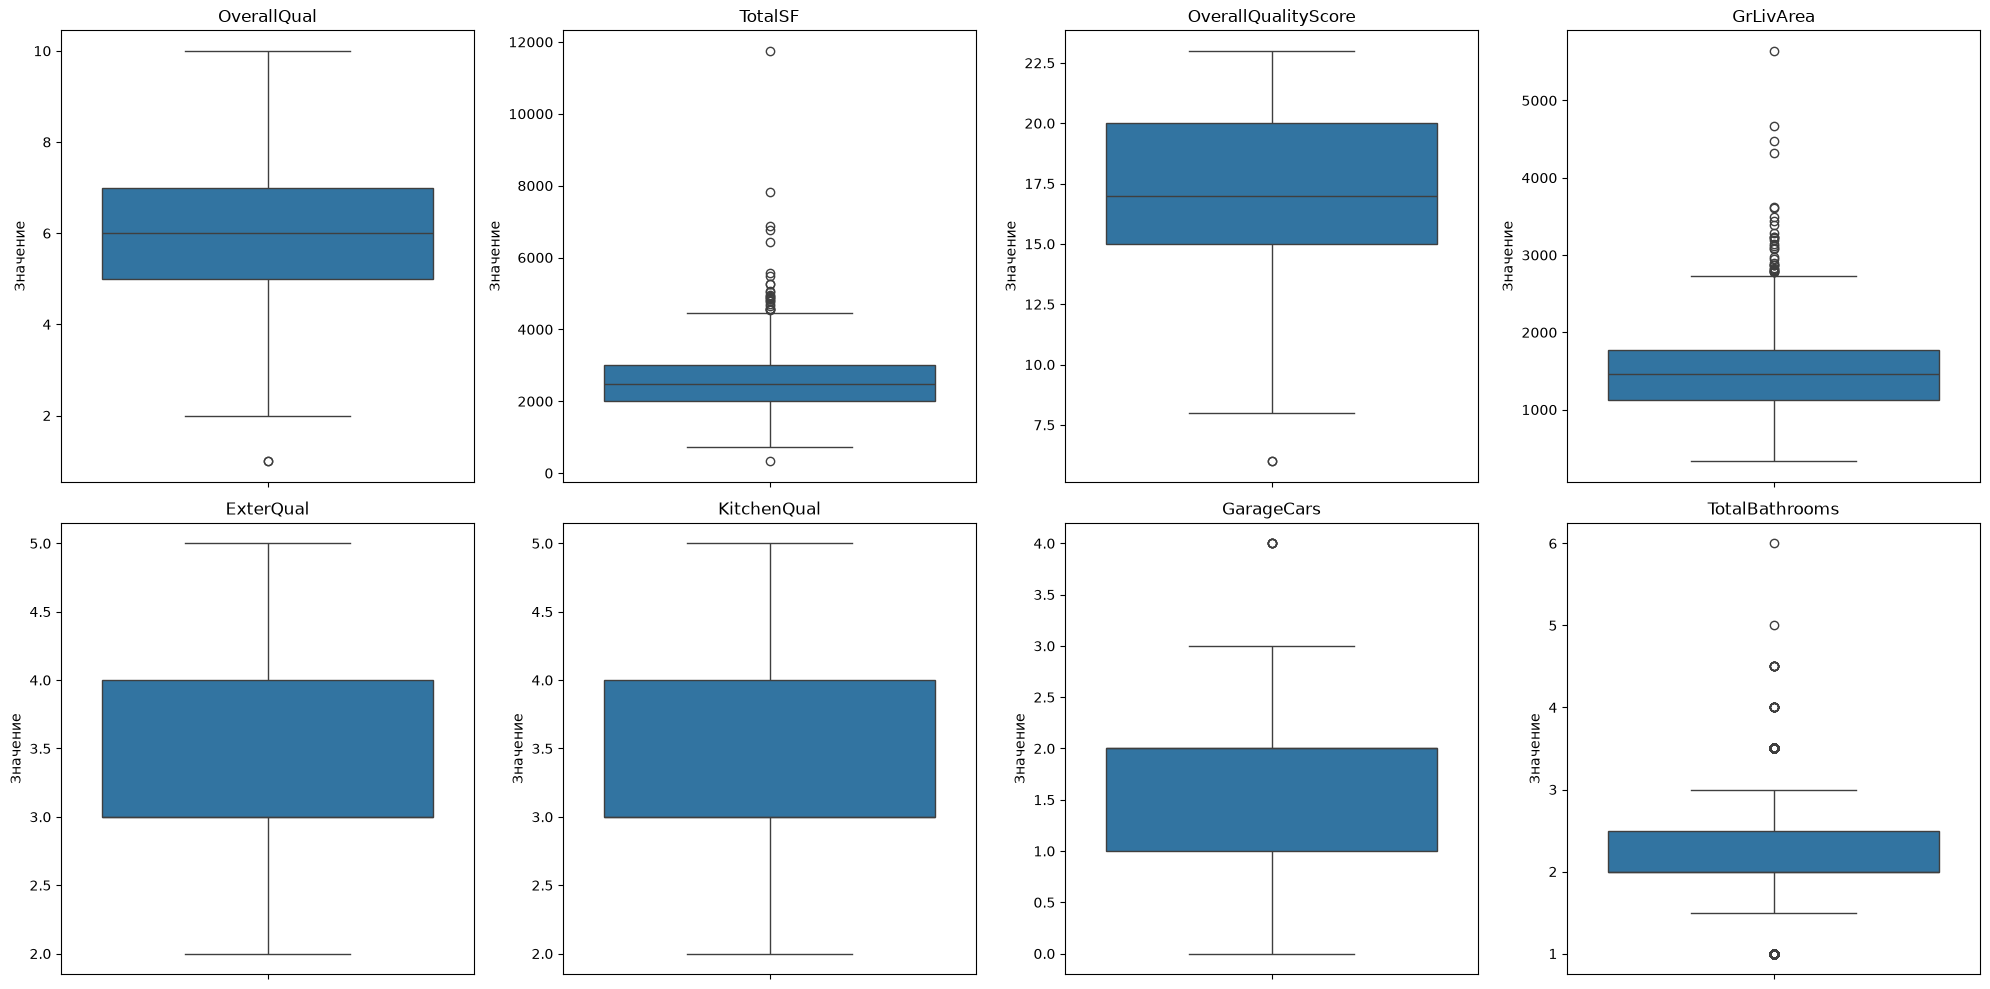

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, col in zip(axes.flatten(), top_features):
    sns.boxplot(y=data[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel("Значение")

plt.tight_layout()
plt.show()

In [15]:
features_for_iqr = [
    "OverallQual",
    "TotalSF",
    "OverallQualityScore",
    "GrLivArea",
    "ExterQual",
    "KitchenQual",
    "GarageCars",
    "TotalBathrooms"
]

for col in features_for_iqr:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower_bound) |
        (data[col] > upper_bound)
    ]

    print(f"\n{col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Нижняя граница: {lower_bound}")
    print(f"Верхняя граница: {upper_bound}")
    print(f"Количество выбросов: {len(outliers)}")


OverallQual
Q1: 5.0
Q3: 7.0
IQR: 2.0
Нижняя граница: 2.0
Верхняя граница: 10.0
Количество выбросов: 2

TotalSF
Q1: 2009.5
Q3: 3004.0
IQR: 994.5
Нижняя граница: 517.75
Верхняя граница: 4495.75
Количество выбросов: 25

OverallQualityScore
Q1: 15.0
Q3: 20.0
IQR: 5.0
Нижняя граница: 7.5
Верхняя граница: 27.5
Количество выбросов: 2

GrLivArea
Q1: 1129.5
Q3: 1776.75
IQR: 647.25
Нижняя граница: 158.625
Верхняя граница: 2747.625
Количество выбросов: 31

ExterQual
Q1: 3.0
Q3: 4.0
IQR: 1.0
Нижняя граница: 1.5
Верхняя граница: 5.5
Количество выбросов: 0

KitchenQual
Q1: 3.0
Q3: 4.0
IQR: 1.0
Нижняя граница: 1.5
Верхняя граница: 5.5
Количество выбросов: 0

GarageCars
Q1: 1.0
Q3: 2.0
IQR: 1.0
Нижняя граница: -0.5
Верхняя граница: 3.5
Количество выбросов: 5

TotalBathrooms
Q1: 2.0
Q3: 2.5
IQR: 0.5
Нижняя граница: 1.25
Верхняя граница: 3.25
Количество выбросов: 394


In [16]:
outliers = data[
    (data["GrLivArea"] > 4000) &
    (data["SalePrice"] < 300000)
]

print("Выбросы:")
print(
    outliers[
        ["GrLivArea", "SalePrice", "OverallQual"]
    ].to_string(index=False)
)

data = data[
    ~(
        (data["GrLivArea"] > 4000) &
        (data["SalePrice"] < 300000)
    )
].copy()

Выбросы:
 GrLivArea  SalePrice  OverallQual
      4676     184750           10
      5642     160000           10


In [17]:
X = data.drop(columns=["SalePrice"])
y = data["SalePrice"]

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

if X_imputed.isnull().sum().sum() == 0:
    print("Пропущенных значений в датафрейме не обнаружено после заполнения.\n")
else:
    print("Остались пропуски после заполнения!\n")

Пропущенных значений в датафрейме не обнаружено после заполнения.



In [18]:
lasso = LassoCV(cv=5, random_state=10)
lasso.fit(X_imputed, y)

coef = pd.Series(lasso.coef_, index=X_imputed.columns)
selected_features = coef[coef != 0].index.tolist()
print("Ненулевые коэффициенты Lasso:\n")
print(coef[coef != 0].sort_values(ascending=False))
print("\nОтобранные признаки для модели:", selected_features)

Ненулевые коэффициенты Lasso:

GarageArea            58.410750
TotalSF               50.646213
MasVnrArea            34.675057
BsmtFinSF1            22.396532
TotalPorchSF          20.892407
YearBuilt             17.793458
GrLivArea             15.570799
YearRemodAdd          12.579271
2ndFlrSF               9.069535
LotArea                0.383353
MiscVal               -0.594676
BsmtFinSF2            -2.868216
YearsSinceRemodel    -67.480550
HouseAge            -234.507881
dtype: float64

Отобранные признаки для модели: ['LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', '2ndFlrSF', 'GrLivArea', 'GarageArea', 'MiscVal', 'HouseAge', 'YearsSinceRemodel', 'TotalSF', 'TotalPorchSF']


In [19]:
X_selected = X_imputed[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=10)
print("\nРазмерности выборок:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)


Размерности выборок:
X_train: (1020, 14) | X_test: (438, 14)


## Линейная регрессия

In [20]:
lr_model = LinearRegression()
neg_mse_lr = cross_val_score(lr_model, X_train, y_train, cv=5, scoring="neg_mean_squared_error")
lr_rmse_cv = np.sqrt(-neg_mse_lr)
print("\nЛинейная регрессия - среднее кросс-валидационное RMSE:", lr_rmse_cv.mean())

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Линейная регрессия - тестовое RMSE:", rmse_lr)


Линейная регрессия - среднее кросс-валидационное RMSE: 35792.41568335525
Линейная регрессия - тестовое RMSE: 34547.90331257634


In [21]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\nЛинейная регрессия метрики:")
print(f"Средняя абсолютная ошибка (MAE): {mae_lr:.2f}")
print(f"Среднеквадратичная ошибка (MSE): {mse_lr:.2f}")
print(f"Корень из среднеквадратичной ошибки (RMSE): {rmse_lr:.2f}")
print(f"Коэффициент детерминации (R²): {r2_lr:.2f}")



Линейная регрессия метрики:
Средняя абсолютная ошибка (MAE): 24051.52
Среднеквадратичная ошибка (MSE): 1193557623.30
Корень из среднеквадратичной ошибки (RMSE): 34547.90
Коэффициент детерминации (R²): 0.80


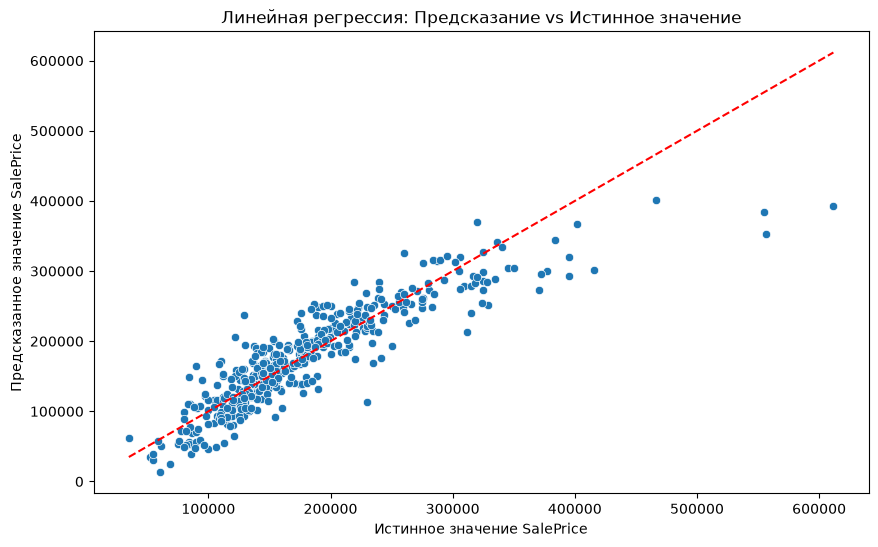

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Истинное значение SalePrice")
plt.ylabel("Предсказанное значение SalePrice")
plt.title("Линейная регрессия: Предсказание vs Истинное значение")
plt.show()

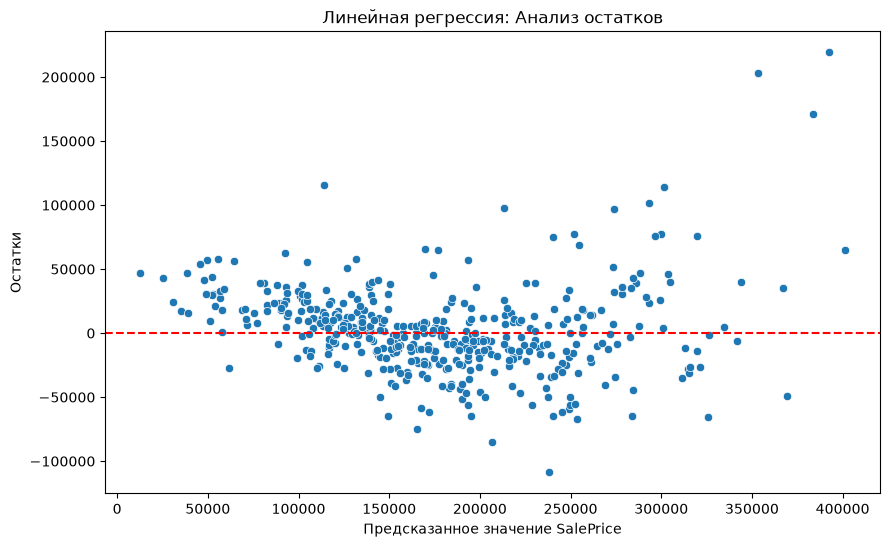

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lr, y=y_test - y_pred_lr)
plt.xlabel("Предсказанное значение SalePrice")
plt.ylabel("Остатки")
plt.axhline(0, color="red", linestyle="--")
plt.title("Линейная регрессия: Анализ остатков")
plt.show()

## Случайный лес

In [24]:
rf = RandomForestRegressor(random_state=10)
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 8, 12],
    "min_samples_split": [2, 5]
}
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print("\nЛучшая конфигурация случайного леса:")
print(grid_search_rf.best_params_)

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nСлучайный лес - тестовое RMSE:", rmse_rf)
print(f"\nСлучайный лес метрики:")
print(f"Средняя абсолютная ошибка (MAE): {mae_rf:.2f}")
print(f"Среднеквадратичная ошибка (MSE): {mse_rf:.2f}")
print(f"Корень из среднеквадратичной ошибки (RMSE): {rmse_rf:.2f}")
print(f"Коэффициент детерминации (R²): {r2_rf:.2f}")


Лучшая конфигурация случайного леса:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Случайный лес - тестовое RMSE: 29755.27150565418

Случайный лес метрики:
Средняя абсолютная ошибка (MAE): 18672.58
Среднеквадратичная ошибка (MSE): 885376182.38
Корень из среднеквадратичной ошибки (RMSE): 29755.27
Коэффициент детерминации (R²): 0.85


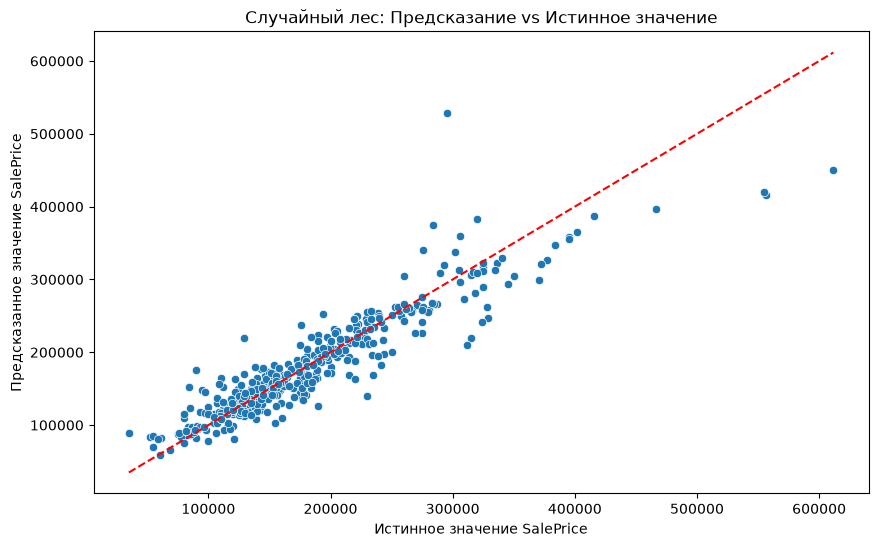

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Истинное значение SalePrice")
plt.ylabel("Предсказанное значение SalePrice")
plt.title("Случайный лес: Предсказание vs Истинное значение")
plt.show()

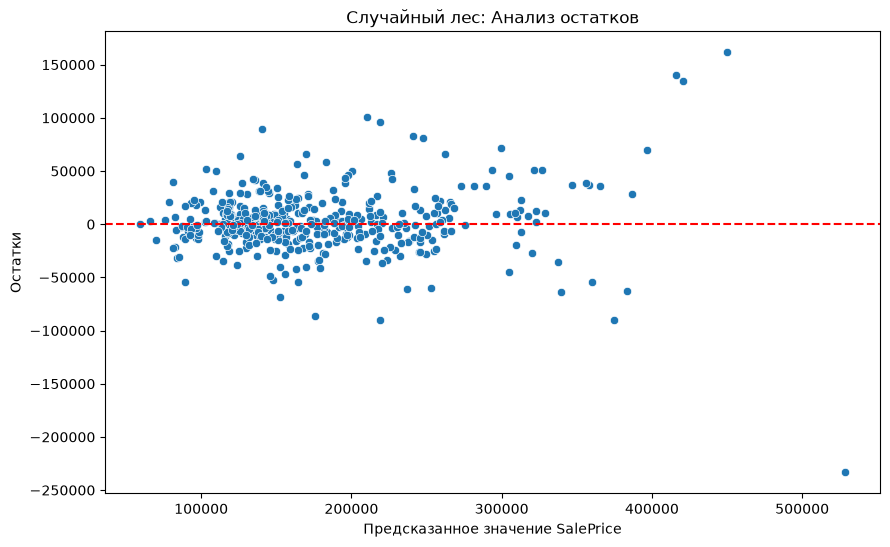

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=y_test - y_pred_rf)
plt.xlabel("Предсказанное значение SalePrice")
plt.ylabel("Остатки")
plt.axhline(0, color="red", linestyle="--")
plt.title("Случайный лес: Анализ остатков")
plt.show()

## CatBoost

In [27]:
X_cat = data.drop(columns=["SalePrice"]).copy()
y_cat = data["SalePrice"].copy()

for col in data_cat_backup.columns:
    X_cat[col] = data_cat_backup.loc[X_cat.index, col]

cat_features = list(data_cat_backup.columns)
print("\nКатегориальные признаки для CatBoost:")
print(cat_features)

for col in cat_features:
    X_cat[col] = X_cat[col].fillna("Missing").astype(str)


Категориальные признаки для CatBoost:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCond', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [28]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.3, random_state=10
)
kf = KFold(n_splits=5, shuffle=True, random_state=10)
cat_rmse_scores = []

for train_idx, val_idx in kf.split(X_train_cat):
    X_tr, X_val = X_train_cat.iloc[train_idx], X_train_cat.iloc[val_idx]
    y_tr, y_val = y_train_cat.iloc[train_idx], y_train_cat.iloc[val_idx]

    fold_model = CatBoostRegressor(
        iterations=500, learning_rate=0.1, depth=6,
        loss_function="RMSE", random_seed=5, verbose=0,
        cat_features=cat_features
    )
    fold_model.fit(X_tr, y_tr)
    pred = fold_model.predict(X_val)
    cat_rmse_scores.append(np.sqrt(mean_squared_error(y_val, pred)))

cat_rmse_scores = np.array(cat_rmse_scores)
print("\nCatBoost - среднее кросс-валидационное RMSE (лог-шкала):", cat_rmse_scores.mean())

cat_model = CatBoostRegressor(
    iterations=500, learning_rate=0.1, depth=6,
    loss_function="RMSE", random_seed=5, verbose=2,
    cat_features=cat_features
)


CatBoost - среднее кросс-валидационное RMSE (лог-шкала): 23855.212641486247


In [29]:
cat_model.fit(X_train_cat, y_train_cat)
y_pred_cat = cat_model.predict(X_test_cat)

rmse_cat = np.sqrt(mean_squared_error(y_test_cat, y_pred_cat))
mae_cat = mean_absolute_error( y_test_cat, y_pred_cat)
mse_cat = mean_squared_error(y_test_cat, y_pred_cat)
r2_cat = r2_score(y_test_cat, y_pred_cat)

print("CatBoost - тестовое RMSE:", rmse_cat)

print("\nCatBoost метрики:")
print(f"MAE:  {mae_cat:.2f}")
print(f"MSE:  {mse_cat:.2f}")
print(f"RMSE: {rmse_cat:.2f}")
print(f"R²:   {r2_cat:.2f}")

0:	learn: 74976.3168186	total: 24.8ms	remaining: 12.4s
2:	learn: 66255.2575021	total: 90ms	remaining: 14.9s
4:	learn: 59293.5135926	total: 167ms	remaining: 16.5s
6:	learn: 52943.8722491	total: 224ms	remaining: 15.8s
8:	learn: 47668.3459122	total: 283ms	remaining: 15.4s
10:	learn: 43696.1219178	total: 337ms	remaining: 15s
12:	learn: 39991.8897221	total: 408ms	remaining: 15.3s
14:	learn: 37063.0199862	total: 471ms	remaining: 15.2s
16:	learn: 34688.7765339	total: 531ms	remaining: 15.1s
18:	learn: 32628.4520240	total: 592ms	remaining: 15s
20:	learn: 30734.4727446	total: 651ms	remaining: 14.8s
22:	learn: 29129.2123572	total: 715ms	remaining: 14.8s
24:	learn: 27767.3194854	total: 778ms	remaining: 14.8s
26:	learn: 26565.0144045	total: 836ms	remaining: 14.6s
28:	learn: 25572.9897054	total: 898ms	remaining: 14.6s
30:	learn: 24762.1615053	total: 960ms	remaining: 14.5s
32:	learn: 23937.4802807	total: 1.02s	remaining: 14.5s
34:	learn: 23227.3628970	total: 1.09s	remaining: 14.5s
36:	learn: 22702.93

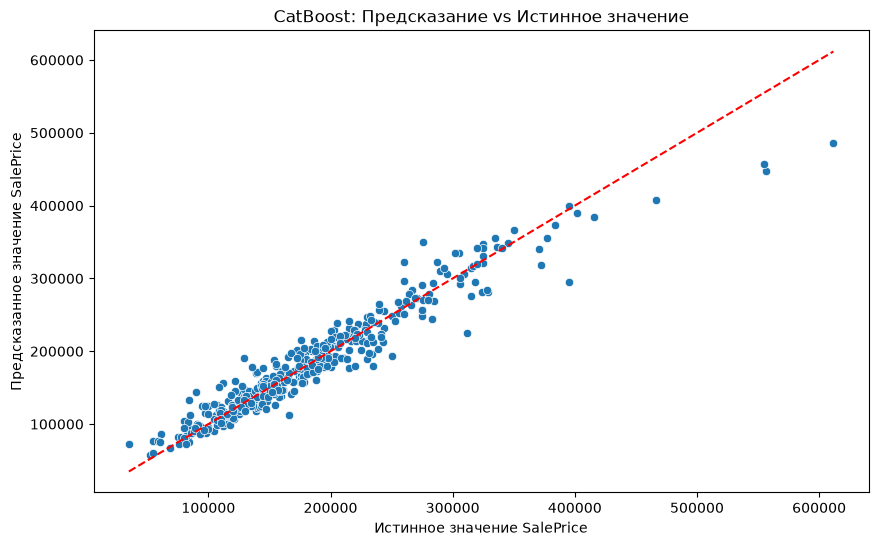

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_cat, y=y_pred_cat)
plt.plot([y_test_cat.min(), y_test_cat.max()], [y_test_cat.min(), y_test_cat.max()], "r--")
plt.xlabel("Истинное значение SalePrice")
plt.ylabel("Предсказанное значение SalePrice")
plt.title("CatBoost: Предсказание vs Истинное значение")
plt.show()

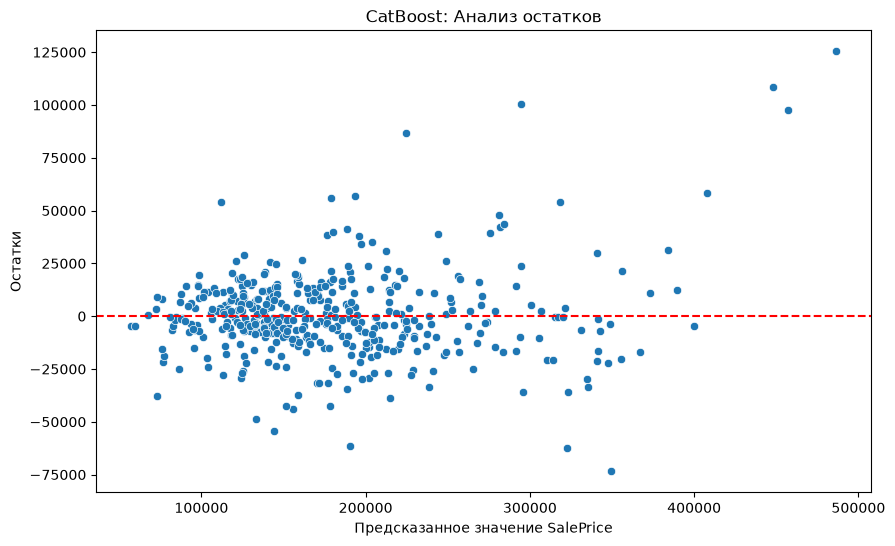

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_cat, y=y_test_cat - y_pred_cat)
plt.xlabel("Предсказанное значение SalePrice")
plt.ylabel("Остатки")
plt.axhline(0, color="red", linestyle="--")
plt.title("CatBoost: Анализ остатков")
plt.show()

In [34]:
print("\n Итоговые метрики моделей")
print(f"Линейная регрессия: MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, RMSE: {rmse_lr:.2f}, R²: {r2_lr:.2f}")
print(f"Случайный лес: MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.2f}")
print(f"CatBoost: MAE: {mae_cat:.2f}, MSE: {mse_cat:.2f}, RMSE: {rmse_cat:.2f}, R²: {r2_cat:.2f}")


 Итоговые метрики моделей
Линейная регрессия: MAE: 24051.52, MSE: 1193557623.30, RMSE: 34547.90, R²: 0.80
Случайный лес: MAE: 18672.58, MSE: 885376182.38, RMSE: 29755.27, R²: 0.85
CatBoost: MAE: 13975.52, MSE: 432362164.79, RMSE: 20793.32, R²: 0.93


Лучшая модель - CatBoost. Она снижает ошибку в абсолютном и квадартичном выражении и объясняет большую часть дисперсии.

